# 01 – Extração e Exploração dos Dados
## UCI SECOM Dataset – Manufacturing Quality Analytics

**Objetivo desta etapa:**
- Carregar os arquivos brutos do dataset SECOM (`secom.data` e `secom_labels.data`)
- Unir sensores + labels em um único DataFrame estruturado
- Explorar a estrutura dos dados: shape, tipos, distribuição de classes e missing values
- Identificar colunas problemáticas antes da etapa de transformação

**Dataset:** 1.567 unidades produzidas | 591 sensores | Label: PASS / FAIL

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Caminhos corrigidos – sobe um nível a partir de /src
BASE_DIR      = os.path.abspath(os.path.join(os.getcwd(), ".."))
RAW_DIR       = os.path.join(BASE_DIR, "data", "raw")
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")

SECOM_DATA    = os.path.join(RAW_DIR, "secom.data")
SECOM_LABELS  = os.path.join(RAW_DIR, "secom_labels.data")

# Confirma os caminhos
print("BASE_DIR     :", BASE_DIR)
print("SECOM_DATA   :", SECOM_DATA)
print("SECOM_LABELS :", SECOM_LABELS)
print("Arquivos existem?", os.path.exists(SECOM_DATA), os.path.exists(SECOM_LABELS))

BASE_DIR     : /Users/dtp/Desktop/projetos_BI/projeto-02-quality-analytics-secom
SECOM_DATA   : /Users/dtp/Desktop/projetos_BI/projeto-02-quality-analytics-secom/data/raw/secom.data
SECOM_LABELS : /Users/dtp/Desktop/projetos_BI/projeto-02-quality-analytics-secom/data/raw/secom_labels.data
Arquivos existem? True True


## 1. Carregamento dos Dados Brutos

O arquivo `secom.data` não possui cabeçalho e usa espaço como separador.
Valores faltantes estão representados como `NaN` no arquivo original.

O `secom_labels.data` contém o resultado da inspeção (PASS/FAIL) e o timestamp de cada unidade.

In [5]:
# Carrega leituras dos sensores
df_sensors = pd.read_csv(SECOM_DATA, sep=" ", header=None, na_values="NaN")
df_sensors.columns = [f"Sensor_{str(i+1).zfill(3)}" for i in range(df_sensors.shape[1])]

print(f"Shape: {df_sensors.shape}")
df_sensors.head()

Shape: (1567, 590)


,Sensor_001,Sensor_002,Sensor_003,Sensor_004,Sensor_005,Sensor_006,Sensor_007,Sensor_008,Sensor_009,Sensor_010,...,Sensor_581,Sensor_582,Sensor_583,Sensor_584,Sensor_585,Sensor_586,Sensor_587,Sensor_588,Sensor_589,Sensor_590
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432


In [7]:
# Carrega labels PASS/FAIL + timestamp
df_labels = pd.read_csv(SECOM_LABELS, sep=" ", header=None, names=["Label", "Timestamp"])

df_labels["Timestamp"] = pd.to_datetime(df_labels["Timestamp"], format="%d/%m/%Y %H:%M:%S", errors="coerce")

df_labels["Result"] = df_labels["Label"].map({1: "PASS", -1: "FAIL"})

print(f"Shape: {df_labels.shape}")
df_labels.head()

Shape: (1567, 3)


,Label,Timestamp,Result
0,-1,2008-07-19 11:55:00,FAIL
1,-1,2008-07-19 12:32:00,FAIL
2,1,2008-07-19 13:17:00,PASS
3,-1,2008-07-19 14:43:00,FAIL
4,-1,2008-07-19 15:22:00,FAIL


In [9]:
# Une sensores + labels 

df = pd.concat([df_labels.reset_index(drop=True), df_sensors.reset_index(drop=True)], axis=1) 

df.insert(0, "Unit_ID", range(1, len(df) + 1)) 
df = df.sort_values("Timestamp").reset_index(drop=True) 

print(f"Shape final: {df.shape}") 
df.head()

Shape final: (1567, 594)


,Unit_ID,Label,Timestamp,Result,Sensor_001,Sensor_002,Sensor_003,Sensor_004,Sensor_005,Sensor_006,...,Sensor_581,Sensor_582,Sensor_583,Sensor_584,Sensor_585,Sensor_586,Sensor_587,Sensor_588,Sensor_589,Sensor_590
0,1,-1,2008-07-19 11:55:00,FAIL,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,2,-1,2008-07-19 12:32:00,FAIL,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,3,1,2008-07-19 13:17:00,PASS,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,4,-1,2008-07-19 14:43:00,FAIL,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,5,-1,2008-07-19 15:22:00,FAIL,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432


## 2. Distribuição de Classes (PASS / FAIL)

- Verificamos o balanceamento do dataset.
- Datasets industriais costumam ser fortemente desbalanceados — muito mais PASS do que FAIL.
- Isso impacta diretamente a escolha de métricas e modelos na etapa de modelagem.

=== Distribuição PASS / FAIL ===
FAIL: 1463 unidades (93.4%)
PASS: 104 unidades (6.6%)


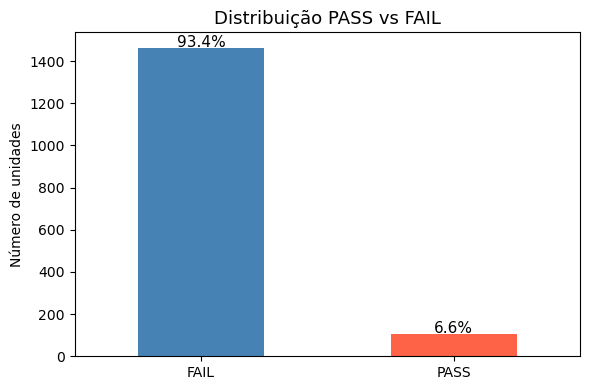

In [15]:
counts = df["Result"].value_counts()
pct    = df["Result"].value_counts(normalize=True) * 100

print("=== Distribuição PASS / FAIL ===")
for label in counts.index:
    print(f"{label}: {counts[label]} unidades ({pct[label]:.1f}%)")

# Gráfico
fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind="bar", color=["steelblue", "tomato"], ax=ax)
ax.set_title("Distribuição PASS vs FAIL", fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("Número de unidades")
ax.set_xticklabels(counts.index, rotation=0)

for i, v in enumerate(counts):
    ax.text(i, v + 5, f"{pct.iloc[i]:.1f}%", ha="center", fontsize=11)
    
plt.tight_layout()
plt.show()


## 3. Análise de Missing Values 

Com 591 sensores, é esperado que muitos tenham dados faltantes. 
A estratégia será: 

- Remover sensores com **mais de 50% de NaN** (pouco confiáveis para análise)
- Imputar pelo valor mediano os sensores restantes com NaN parcial 
- Registrar quantas colunas foram removidas e quantas foram imputadas

In [18]:
# % de missing por coluna (apenas sensores)
sensor_cols  = [c for c in df.columns if c.startswith("Sensor_")]
missing_pct  = df[sensor_cols].isnull().mean().sort_values(ascending=False)

print(f"Total de sensores          : {len(sensor_cols)}")
print(f"Sensores com algum missing : {(missing_pct > 0).sum()}")
print(f"Sensores com >50% missing  : {(missing_pct > 0.50).sum()}")
print(f"Sensores com >80% missing  : {(missing_pct > 0.80).sum()}")
print(f"Sensores sem nenhum missing: {(missing_pct == 0).sum()}")

print("\n=== TOP 20 sensores com mais missing ===")
print(missing_pct.head(20).to_string())

Total de sensores          : 590
Sensores com algum missing : 538
Sensores com >50% missing  : 28
Sensores com >80% missing  : 8
Sensores sem nenhum missing: 52

=== TOP 20 sensores com mais missing ===
Sensor_158    0.911934
Sensor_293    0.911934
Sensor_294    0.911934
Sensor_159    0.911934
Sensor_493    0.855775
Sensor_359    0.855775
Sensor_086    0.855775
Sensor_221    0.855775
Sensor_247    0.649649
Sensor_110    0.649649
Sensor_111    0.649649
Sensor_112    0.649649
Sensor_519    0.649649
Sensor_517    0.649649
Sensor_246    0.649649
Sensor_245    0.649649
Sensor_383    0.649649
Sensor_384    0.649649
Sensor_385    0.649649
Sensor_518    0.649649


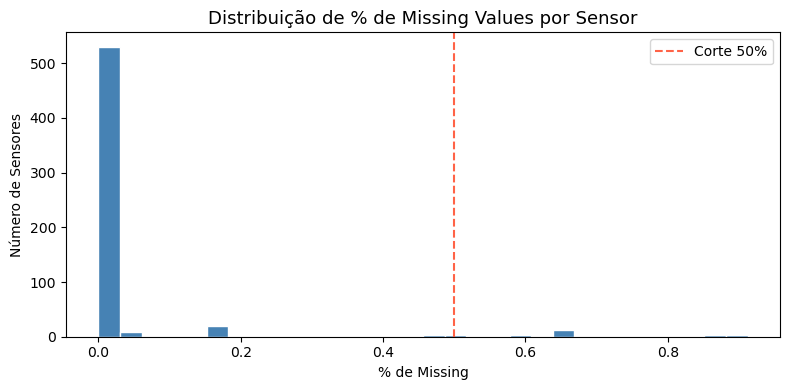

In [20]:
# Histograma da distribuição de % missing
fig, ax = plt.subplots(figsize=(8, 4))
missing_pct.plot(kind="hist", bins=30, color="steelblue", edgecolor="white", ax=ax)
ax.axvline(0.50, color="tomato", linestyle="--", label="Corte 50%")
ax.set_title("Distribuição de % de Missing Values por Sensor", fontsize=13)
ax.set_xlabel("% de Missing")
ax.set_ylabel("Número de Sensores")
ax.legend()

plt.tight_layout()
plt.show()

## Com base nesses números analisados

---

Com base nesses números:

- 590 sensores no total
- 538 com algum missing
- 28 com mais de 50% de missing
- 08 com mais de 80% de missing
- 52 sensores sem missing

---

Uma regra bem razoável para o 02_transform.py será:

- Remover sensores com mais de 50% de missing.
- Para os demais sensores, imputar os NaN pela mediana.
- Manter todos os sensores que sobreviverem a esse corte.

## 4. Conclusões desta Etapa

Com base na exploração acima, identificamos:

- **Shape do dataset:** 1.567 unidades × 594 colunas (591 sensores + Unit_ID + Label + Timestamp + Result)
  
- **Desbalanceamento:** ~93% FAIL / ~7% PASS → exige atenção especial na modelagem
  
**Dataset é naturalmente desbalanceado**  

Em processos industriais:
    
    - Normalmente o que é raro é a falha final (FAIL) em relação ao total produzido.
      
    - Mas no SECOM, o que foi disponibilizado não é “toda a produção”.
      
    - É um subconjunto de situações monitoradas/testes específicos, e muitos desses registros são de “casos problemáticos”.
      
**O que a própria UCI comenta**

O dataset foi criado para estudo de **deteção de falhas**, não como um espelho perfeito da linha real. É comum que datasets de pesquisa sejam “enriquecidos” com mais casos de interesse (falhas) para análise.


- Do ponto de vista matemático, a leitura está correta.
- Do ponto de vista de negócio, podemos interpretar que:  
  
    “Esse conjunto de dados foi construído com foco em situações de falha (FAIL), por isso a proporção é alta. Não é exatamente o espelho de toda a produção, mas um recorte orientado à análise de problemas.”
    

- **Missing values:** grande parte dos sensores possui algum dado faltante
  - Sensores com >50% de NaN serão **removidos** na etapa de transformação
  - Sensores com NaN parcial serão **imputados pela mediana**

**Próxima etapa:** `02_transform.py` / `02_transform.ipynb` – limpeza, imputação e preparação da base final para o Tableau.